In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Standard AR(1):
$$x_t = \mu + \rho x_{t-1} + \xi_t$$
Here showing for different values of $\rho$ ($|\rho| < 1$: stationary, $\rho = 1$: random walk, $\rho > 1$: explosive root) kepping $\mu = 0$ and $\xi_t \sim N(0, \sigma^2), \sigma = 1$ constant for the different simulations. Just to show behavior of the $\rho$ parameter under different values.  

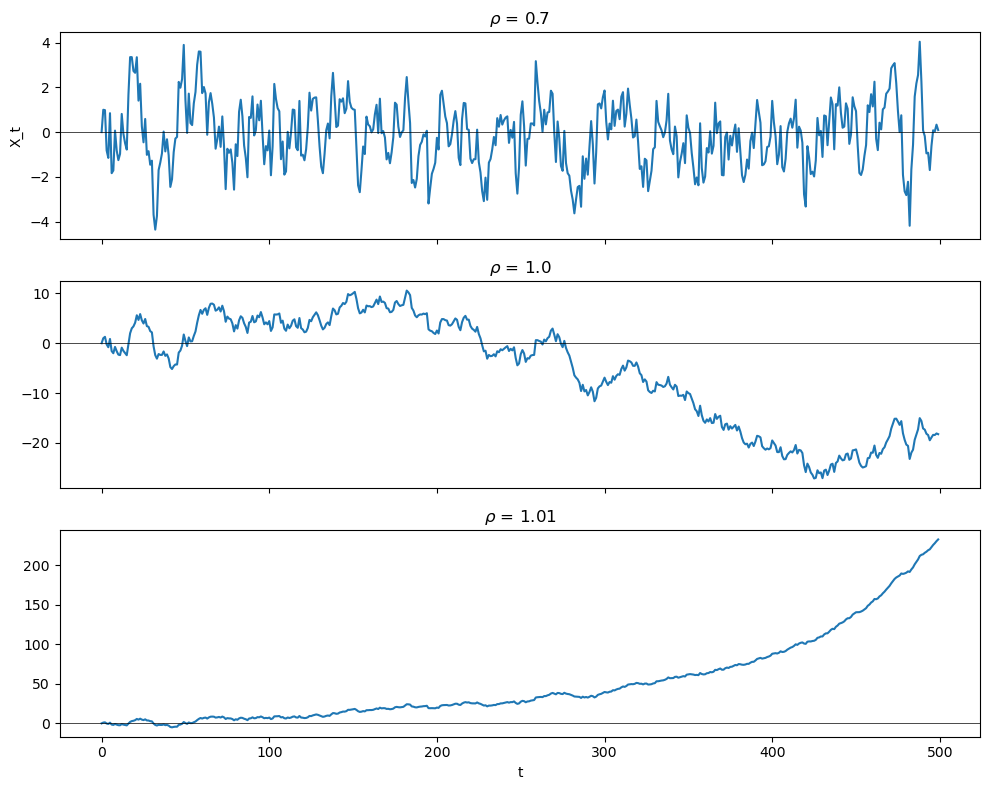

In [40]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_ar1(T=200, rho=0.8, sigma=1.0, x0=0.0, seed=None):
    if seed is not None:
        np.random.seed(seed)
    eps = np.random.normal(0, sigma, size=T)
    x = np.zeros(T)
    x[0] = x0
    for t in range(1, T):
        x[t] = rho * x[t-1] + eps[t]
    return x

# Rhos you want
rhos = [0.7, 1.0, 1.01]
T = 500

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes = axes.ravel()

for i, rho in enumerate(rhos):
    x = simulate_ar1(T=T, rho=rho, sigma=1.0, x0=0.0, seed=123)
    ax = axes[i]
    ax.plot(x)
    ax.set_title(r"$\rho$ = " + str(rho))
    ax.axhline(0, color="black", linewidth=0.5)
    if i == len(rhos) - 1:   # only bottom subplot
        ax.set_xlabel("t")
    if i == 0:
        ax.set_ylabel("X_t")

plt.tight_layout()
plt.show()